KNN

how to choose the value of k?

1)heuristic  take root n and then take the odd number like root of 400 is 20 but take 19 or 21(odd)

2)experimentation:need to check by cross validation(in which the accuracy is high at the time of training)

model affecting by value of k

k(very low)=overfitting

k(intermediate)=good model

k(high)=underfitting

failure cases

*ouliers
*imbalanced dataset
*non-homogeneous scales
*inferene for prediction(can't explain others how the output is created)

In [ ]:
#import necessary libraries



In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
df=pd.read_csv('knn_customer_dataset_240_rows.csv')
df.head()

,Customer_ID,Age,Annual_Spending_k,target
0,C025,41,67.9,High Value
1,C007,38,58.0,Low Value
2,C094,58,62.0,High Value
3,C110,54,92.8,High Value
4,C105,56,63.1,Low Value


In [3]:
df.shape

(240, 4)

In [4]:
df.info

<bound method DataFrame.info of     Customer_ID  Age  Annual_Spending_k      target
0          C025   41               67.9  High Value
1          C007   38               58.0   Low Value
2          C094   58               62.0  High Value
3          C110   54               92.8  High Value
4          C105   56               63.1   Low Value
..          ...  ...                ...         ...
235        C107   59               72.5  High Value
236        C015   22               29.8   Low Value
237        C093   24               35.2   Low Value
238        C180   47               74.1  High Value
239        C103   42               64.1   Low Value

[240 rows x 4 columns]>

In [8]:
target_columns="target"
X=df.drop(columns=[target_columns])
y=df[target_columns]
X.head()

,Customer_ID,Age,Annual_Spending_k
0,C025,41,67.9
1,C007,38,58.0
2,C094,58,62.0
3,C110,54,92.8
4,C105,56,63.1


In [10]:
y.head()

0    High Value
1     Low Value
2    High Value
3    High Value
4     Low Value
Name: target, dtype: str

In [9]:
y.value_counts()

target
Low Value     126
High Value    114
Name: count, dtype: int64

In [11]:
X=X.select_dtypes(include=np.number)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (192, 2)
Test set size: (48, 2)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
knn= KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['High Value','Low Value']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [14]:
y_pred=knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 0.9166666666666666


In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  High Value       0.88      0.96      0.92        23
   Low Value       0.96      0.88      0.92        25

    accuracy                           0.92        48
   macro avg       0.92      0.92      0.92        48
weighted avg       0.92      0.92      0.92        48



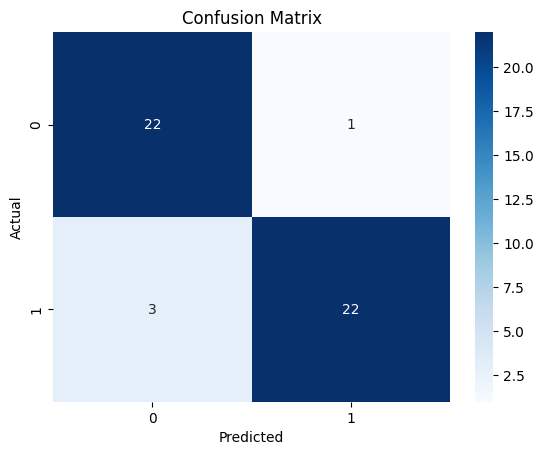

In [19]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()